# Load Project Data

In [1]:
import numpy as np
import pandas as pd
import gdown
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp
import math
# from scipy.stats import zscore
import warnings
warnings.filterwarnings('ignore')

In [2]:
# ==============================
# Load Project Data
# ==============================

gid_path = "1qvELtIxFwFRJ3lLPI0PvLrhH_6VPwxXY"

gdown.download(
    id = gid_path,
    output="get_it_done_requests_closed_2025_datasd.csv",
    quiet=False
)

gid_requests = pd.read_csv("get_it_done_requests_closed_2025_datasd.csv")

Downloading...
From (original): https://drive.google.com/uc?id=1qvELtIxFwFRJ3lLPI0PvLrhH_6VPwxXY
From (redirected): https://drive.google.com/uc?id=1qvELtIxFwFRJ3lLPI0PvLrhH_6VPwxXY&confirm=t&uuid=1c4c47db-1bfa-4243-8ecc-1dff1b3301e6
To: /content/get_it_done_requests_closed_2025_datasd.csv
100%|██████████| 128M/128M [00:02<00:00, 59.2MB/s]


# High-Level Overview and MetaData Report

In [3]:
gid_requests.shape

(378669, 23)

In [4]:
gid_requests.head()

,service_request_id,service_request_parent_id,sap_notification_number,date_requested,case_age_days,case_record_type,service_name,service_name_detail,date_closed,status,...,zipcode,council_district,comm_plan_code,comm_plan_name,park_name,case_origin,referred,iamfloc,floc,public_description
0,5152704,NaN,NaN,2025-03-19 16:20:00.000,0,TSW,Pothole,NaN,2025-03-19,Referred,...,NaN,6.0,15.0,MIRA MESA,NaN,Mobile,This report has been referred to appropriate d...,SS-001649-PV1,SS-001649-PV1,Broken cover. || LOCATION: 7489 Acama st 92126...
1,5152705,NaN,NaN,2025-03-19 16:22:00.000,1,ESD Complaint/Report,Missed Collection,Missed Collection,2025-03-20,Closed,...,92109.0,2.0,18.0,MISSION BEACH,NaN,Web,NaN,SS-035651-PV1,SA-002923-PV1,Third attempt has not been picked up
2,5152711,NaN,NaN,2025-03-19 16:25:00.000,27,Parking,Parking Violation,72 Hour Violation,2025-04-15,Closed,...,92117.0,2.0,6.0,CLAIREMONT MESA,NaN,Web,NaN,SS-013181,SS-013181,Van has been parked for over a month. Windows ...
3,5152712,NaN,NaN,2025-03-19 16:25:00.000,14,Neighborhood Policing,Encampment,NaN,2025-04-02,Closed,...,92101.0,2.0,14.0,MIDWAY-PACIFIC HIGHWAY,NaN,Web,NaN,SS-030076-PV1,SS-030076-PV1,A homeless encampment fire was reported at W. ...
4,5152714,NaN,NaN,2025-03-19 16:29:00.000,3,Parking,Parking Violation,72 Hour Violation,2025-03-22,Closed,...,92110.0,2.0,6.0,CLAIREMONT MESA,NaN,Web,NaN,SS-018336,SS-018336,Van has been parked on the curb since March 11...


In [5]:
gid_requests.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 378669 entries, 0 to 378668
Data columns (total 23 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   service_request_id         378669 non-null  int64  
 1   service_request_parent_id  41999 non-null   float64
 2   sap_notification_number    46831 non-null   float64
 3   date_requested             378669 non-null  object 
 4   case_age_days              378669 non-null  int64  
 5   case_record_type           378669 non-null  object 
 6   service_name               378489 non-null  object 
 7   service_name_detail        240280 non-null  object 
 8   date_closed                378669 non-null  object 
 9   status                     378669 non-null  object 
 10  lat                        378270 non-null  float64
 11  lng                        378270 non-null  float64
 12  street_address             377569 non-null  object 
 13  zipcode                    37

In [6]:
gid_requests["zipcode"] = (
    gid_requests["zipcode"]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
)

gid_requests["comm_plan_code"] = (
    gid_requests["comm_plan_code"]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
)

gid_requests["council_district"] = (
    gid_requests["council_district"]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
)

Observed that there are no integer-coded categorical features that need to be switched to categorical types

In [7]:
gid_requests.nunique()

,0
service_request_id,378669
service_request_parent_id,25696
sap_notification_number,46830
date_requested,234665
case_age_days,2442
case_record_type,12
service_name,42
service_name_detail,262
date_closed,365
status,2


In [8]:
def create_metadata(df) :
    # Initialize DataFrame object with index (row names) as feature names
    meta = pd.DataFrame(index=df.columns)
    # Extract variable types
    meta['dtype'] = df.dtypes
    # Extract number of unique values
    meta['n_unique'] = df.nunique()
    # Number of missing values
    meta['missing_sum'] = df.isnull().sum()
    # Whether feature is numeric
    meta['is_numeric'] = meta['dtype'].apply(
        lambda x: pd.api.types.is_numeric_dtype(x)
    )
    # Whether feature is categorical
    meta['is_categorical'] = meta['dtype'].apply(
        lambda x: isinstance(x, pd.CategoricalDtype) or x == object
    )
    # Sample of values (that are not missing) from dataset
    #meta['sample_values'] = df.apply(lambda col: col.dropna().unique()[:5])
    # Return metadata DataFrame
    return meta

# Run the method on DataFrame and generate report
meta_df = create_metadata(gid_requests)

# Export to CSV file
meta_df.to_csv("metadata_report.csv")

meta_df.head(25)

,dtype,n_unique,missing_sum,is_numeric,is_categorical
service_request_id,int64,378669,0,True,False
service_request_parent_id,float64,25696,336670,True,False
sap_notification_number,float64,46830,331838,True,False
date_requested,object,234665,0,False,True
case_age_days,int64,2442,0,True,False
case_record_type,object,12,0,False,True
service_name,object,42,180,False,True
service_name_detail,object,262,138389,False,True
date_closed,object,365,0,False,True
status,object,2,0,False,True


# Exploratory Data Analysis

In [9]:
# Count, Mean, Standard Deviation, Min,
# Q1, Median, Q3, Max
summary = gid_requests.describe(include = "int64").T

# Skewness describes whether data is assymetric (not centered)
summary["skew"] = gid_requests.select_dtypes(
    include = "int64"
).skew()

# Kurtosis describes whether data is heavy-tailed (outliers)
summary["kurtosis"] = gid_requests.select_dtypes(
    include = "int64"
).kurt()

summary

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
service_request_id,378669.0,5.221576e+06,297641.883433,82529.0,5138245.0,5253320.0,5373489.0,5606526.0,-6.794564,79.371714
case_age_days,378669.0,4.609077e+01,194.383769,-124.0,0.0,2.0,14.0,3478.0,8.064617,81.012409


Observe that case_age_days is probably the only numeric column here with any real meaning

In [10]:
def plot_boxplot_grid(
    df, cols_per_row=5, figsize_per_plot=(4, 3),
    title='Boxplots of Numeric Features'
):
    # Extract numeric features & calculate plots per row in grid
    numeric_cols = df.select_dtypes(include='int64').columns
    n_cols = len(numeric_cols)

    # Determine grid size
    n_rows = math.ceil(n_cols / cols_per_row)

    # Setup subplots
    fig, axes = plt.subplots(
        n_rows, cols_per_row,
        figsize=(cols_per_row * figsize_per_plot[0],
                 n_rows * figsize_per_plot[1])
    )
    axes = axes.flatten()

    # Create each boxplot
    for i, col in enumerate(numeric_cols):
        sns.boxplot(y=df[col], ax=axes[i])
        axes[i].set_title(col)
        axes[i].set_xlabel("")

    # Hide unused axes
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.suptitle(title, fontsize=16, y=1.02)
    plt.show()

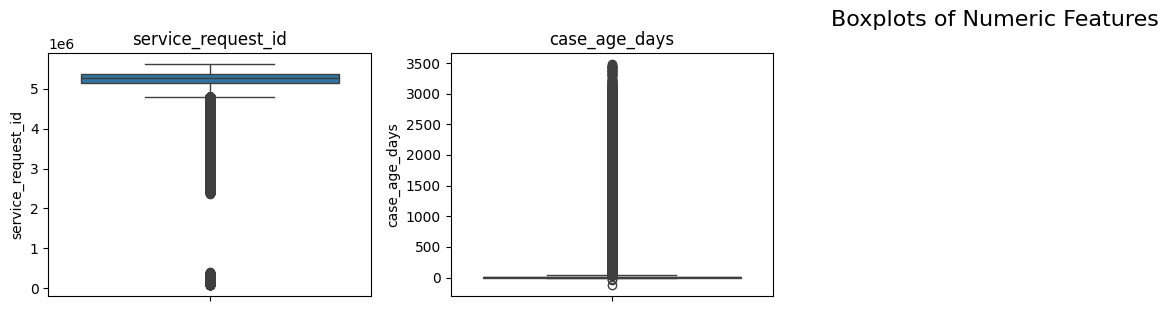

In [11]:
plot_boxplot_grid(df = gid_requests)

Some outliers are squishing the box plot for case age days (don't really care about service request ID)

In [12]:
gid_requests["case_age_days"].quantile(
    [0.50, 0.75, 0.90, 0.95, 0.99, 1.00]
)

,case_age_days
0.50,2.00
0.75,14.00
0.90,67.00
0.95,182.00
0.99,958.32
1.00,3478.00


Boxplot for case age days with outliers removed

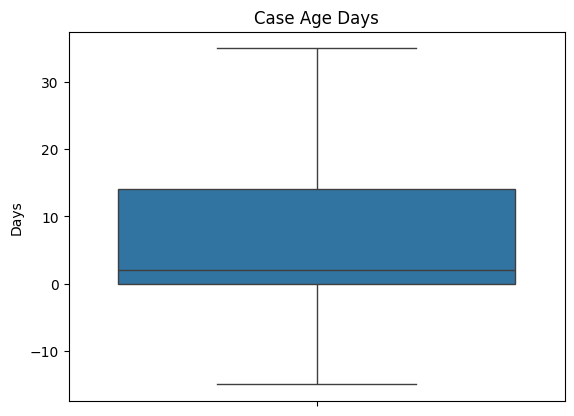

In [13]:
sns.boxplot(
    y=gid_requests["case_age_days"],
    showfliers=False
)

plt.title("Case Age Days")
plt.ylabel("Days")
plt.show()

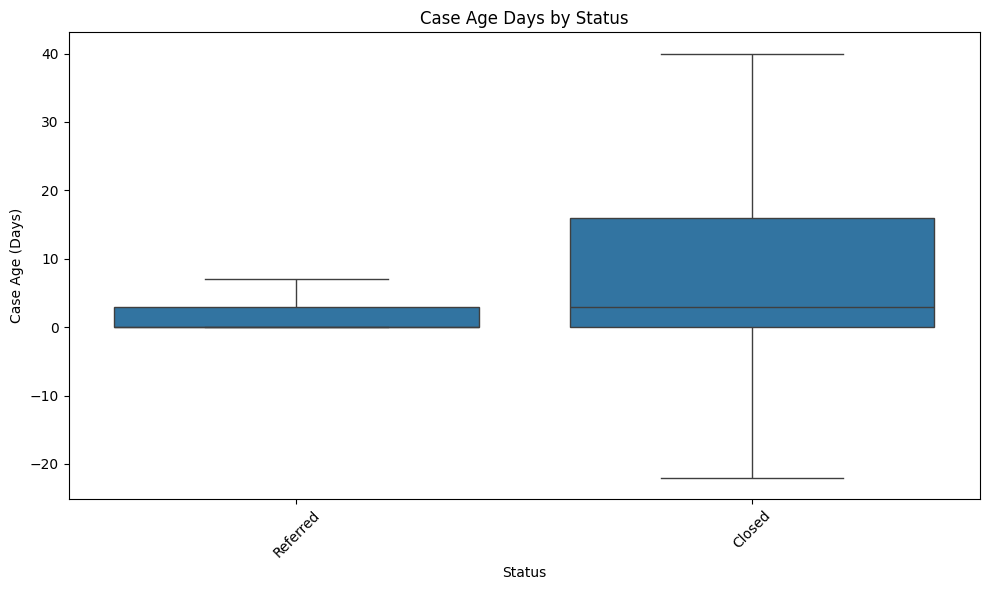

In [14]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=gid_requests,
    x="status",
    y="case_age_days",
    showfliers=False
)

plt.title("Case Age Days by Status")
plt.xlabel("Status")
plt.ylabel("Case Age (Days)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
(gid_requests["status"] == "Referred").sum()

np.int64(27958)

Going to remove cases referred

Inspecting outliers in code below (15 standard deviations from mean for case age days) - going to leave them in for now

In [16]:
# Filter to Closed cases
closed_cases = gid_requests[gid_requests["status"] == "Closed"].copy()

# Calculate mean and standard deviation
mean_age = closed_cases["case_age_days"].mean()
std_age = closed_cases["case_age_days"].std()

# Define +/- 3 standard deviations
lower_bound = mean_age - (15 * std_age)
upper_bound = mean_age + (15 * std_age)

# Find cases outside those bounds
closed_outliers = closed_cases[
    (closed_cases["case_age_days"] < lower_bound) |
    (closed_cases["case_age_days"] > upper_bound)
]


print(closed_outliers.shape)
closed_outliers.head()

(57, 23)


,service_request_id,service_request_parent_id,sap_notification_number,date_requested,case_age_days,case_record_type,service_name,service_name_detail,date_closed,status,...,zipcode,council_district,comm_plan_code,comm_plan_name,park_name,case_origin,referred,iamfloc,floc,public_description
75683,86874,NaN,4.030000e+10,2016-06-08 18:45:00.000,3478,TSW,Pavement Maintenance,DAMAGED CURB,2025-12-16,Closed,...,nan,9,58,MID-CITY:KENSINGTON-TALMADGE,NaN,Mobile,NaN,SS-015118-PV1,SS-015118,Curb and sidewalk came in damaged for over thr...
75684,91703,NaN,4.030000e+10,2016-07-05 21:26:00.000,3465,TSW,Pavement Maintenance,DAMAGED CURB,2025-12-30,Closed,...,nan,9,59,MID-CITY:NORMAL HEIGHTS,NaN,Mobile,NaN,SS-000937-PV1,SS-000937,It was broken when a city crew replaced the fi...
75685,93180,NaN,4.030000e+10,2016-07-13 15:56:00.000,3313,TSW,Pavement Maintenance,DAMAGED CURB,2025-08-08,Closed,...,nan,3,42,UPTOWN,NaN,Mobile,NaN,SS-029821-PV1,SS-029821,"Curb needs replacement, trip hazard, north cur..."
75686,95710,NaN,4.030000e+10,2016-07-25 20:30:00.000,3431,TSW,Pavement Maintenance,DAMAGED CURB,2025-12-16,Closed,...,nan,9,58,MID-CITY:KENSINGTON-TALMADGE,NaN,Web,NaN,SS-017647-PV1,SS-017647,The curb in front of our home is deteriorating...
75907,94155,NaN,4.030001e+10,2016-07-18 16:02:00.000,3411,TSW,Stormwater,DRAIN OUTFALL,2025-11-19,Closed,...,nan,3,42,UPTOWN,NaN,Web,NaN,OT00225,SS-012872,We have no drain from North Guy Street (upper)...


Removal of referred requests

In [17]:
closed_requests = gid_requests[
    gid_requests["status"] == "Closed"
].copy()

closed_requests["council_district"] = closed_requests["council_district"].astype("category")

In [18]:
# Count, Mean, Standard Deviation, Min,
# Q1, Median, Q3, Max
summary = closed_requests.describe(include = "int64").T

# Skewness describes whether data is assymetric (not centered)
summary["skew"] = closed_requests.select_dtypes(
    include = "int64"
).skew()

# Kurtosis describes whether data is heavy-tailed (outliers)
summary["kurtosis"] = closed_requests.select_dtypes(
    include = "int64"
).kurt()

summary

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
service_request_id,350711.0,5.218711e+06,306173.160809,82529.0,5137513.5,5253421.0,5373329.5,5606526.0,-6.685886,75.751919
case_age_days,350711.0,4.911907e+01,201.127902,-124.0,0.0,3.0,16.0,3478.0,7.793137,75.474397


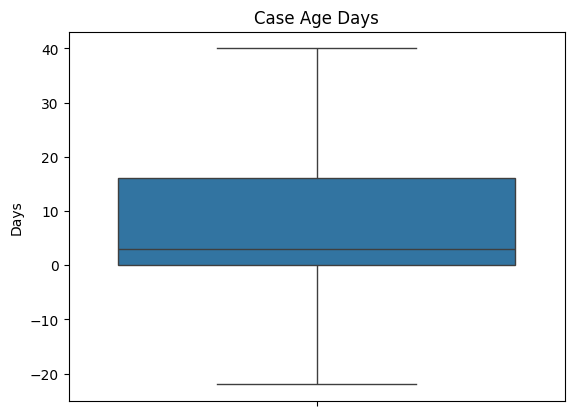

In [19]:
sns.boxplot(
    y=closed_requests["case_age_days"],
    showfliers=False
)

plt.title("Case Age Days")
plt.ylabel("Days")
plt.show()

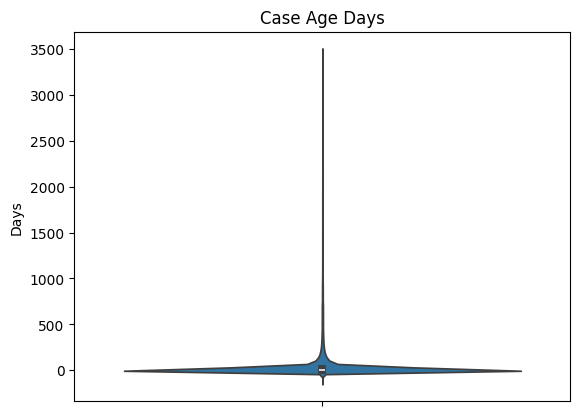

In [20]:
sns.violinplot(
    y=closed_requests["case_age_days"]
)

plt.title("Case Age Days")
plt.ylabel("Days")
plt.show()

Lots of skew, going to keep outliers for now but might consider removing them later on

Box plots by categorical features (case record type and council district)

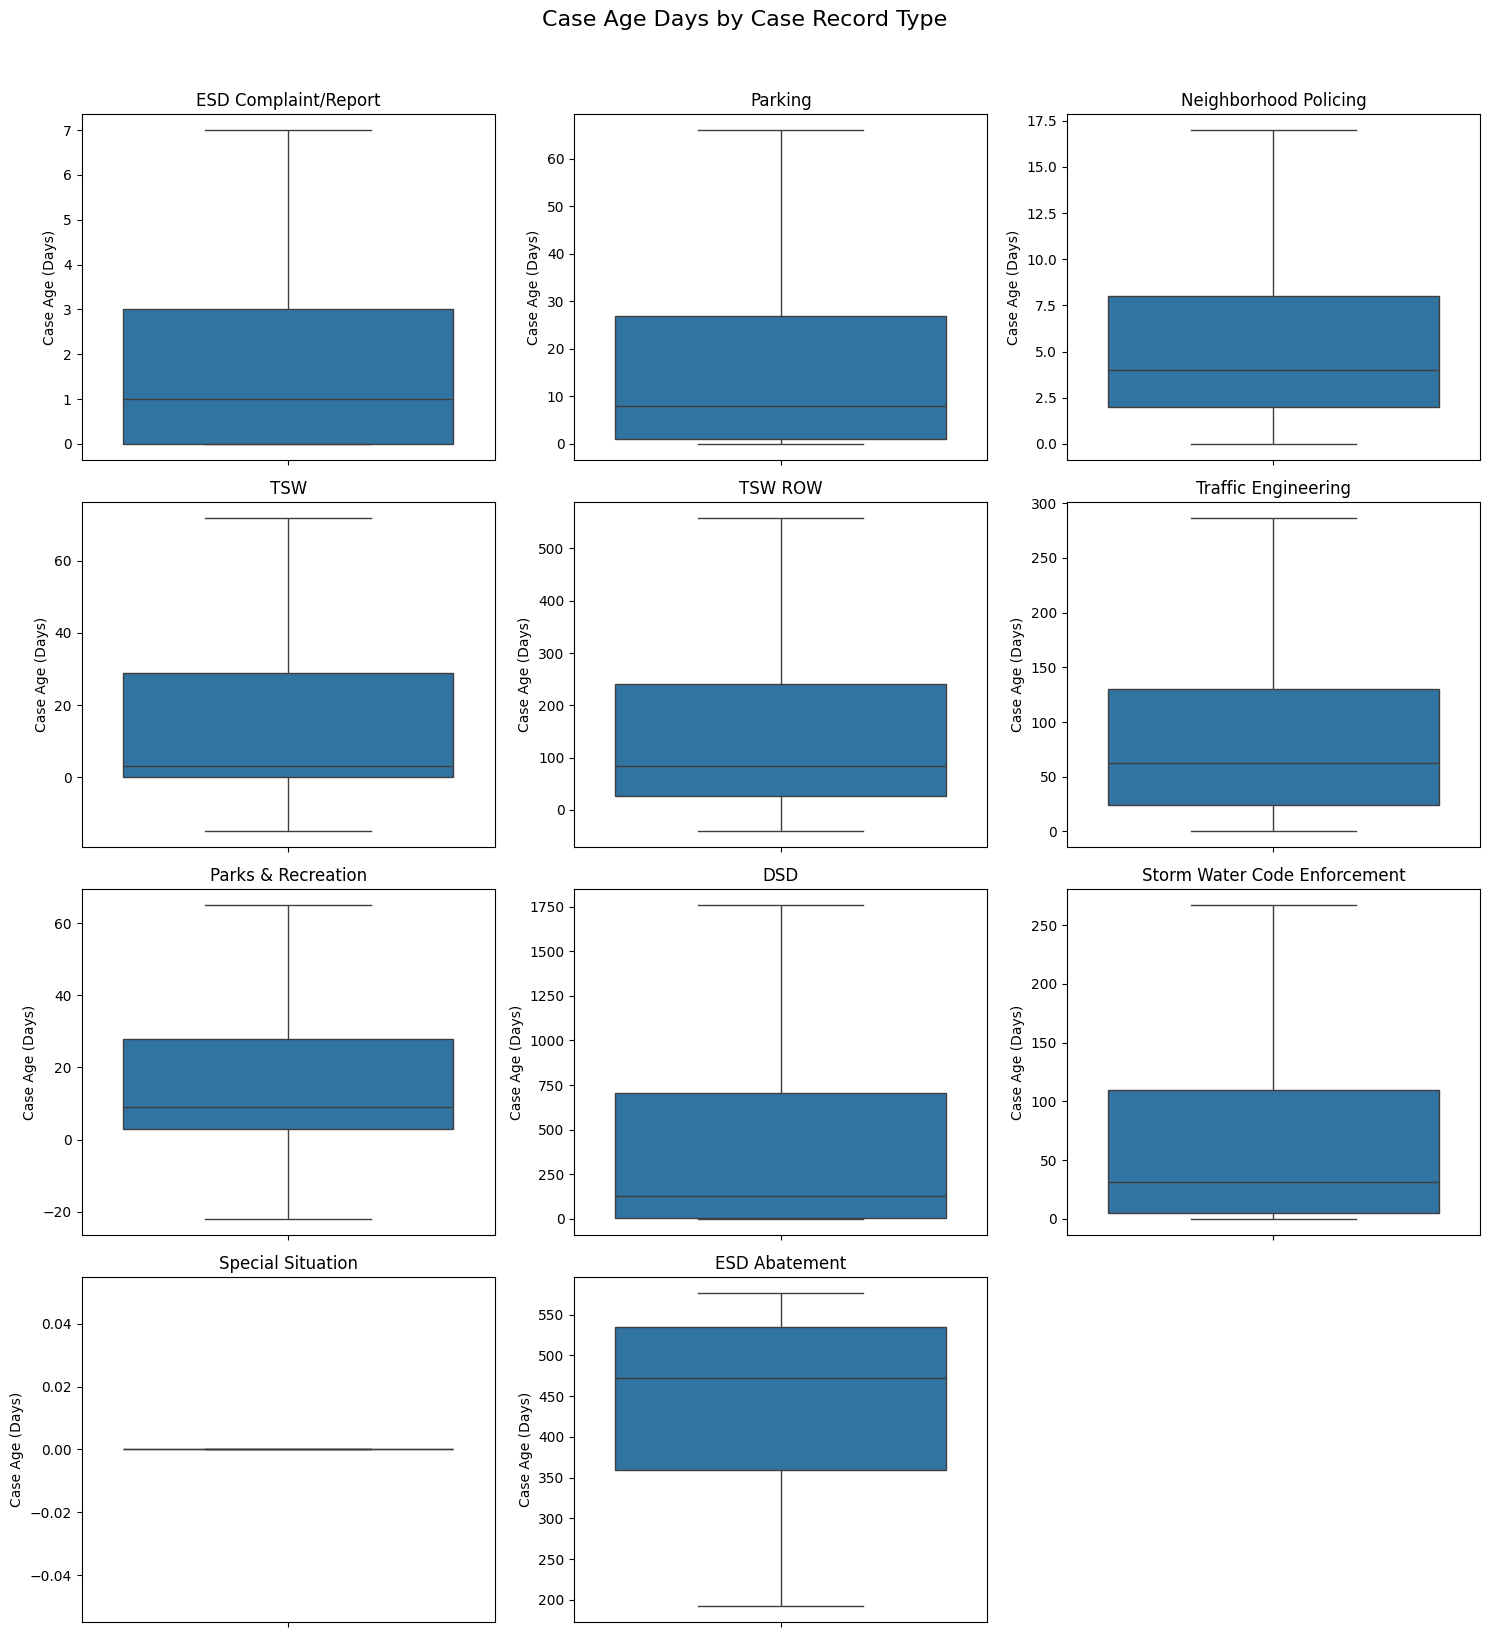

In [21]:
# Get all unique case record types
record_types = closed_requests["case_record_type"].dropna().unique()

# Number of plots per row
cols_per_row = 3

# Calculate number of rows needed
n_rows = math.ceil(len(record_types) / cols_per_row)

# Create grid
fig, axes = plt.subplots(
    n_rows,
    cols_per_row,
    figsize=(15, 4 * n_rows)
)

# Flatten axes so they're easier to loop through
axes = axes.flatten()

# Create one boxplot for each case record type
for i, record_type in enumerate(record_types):

    subset = closed_requests[
        closed_requests["case_record_type"] == record_type
    ]

    sns.boxplot(
        y=subset["case_age_days"],
        ax=axes[i],
        showfliers=False
    )

    axes[i].set_title(record_type)
    axes[i].set_ylabel("Case Age (Days)")
    axes[i].set_xlabel("")

# Remove unused plots
for j in range(len(record_types), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    "Case Age Days by Case Record Type",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

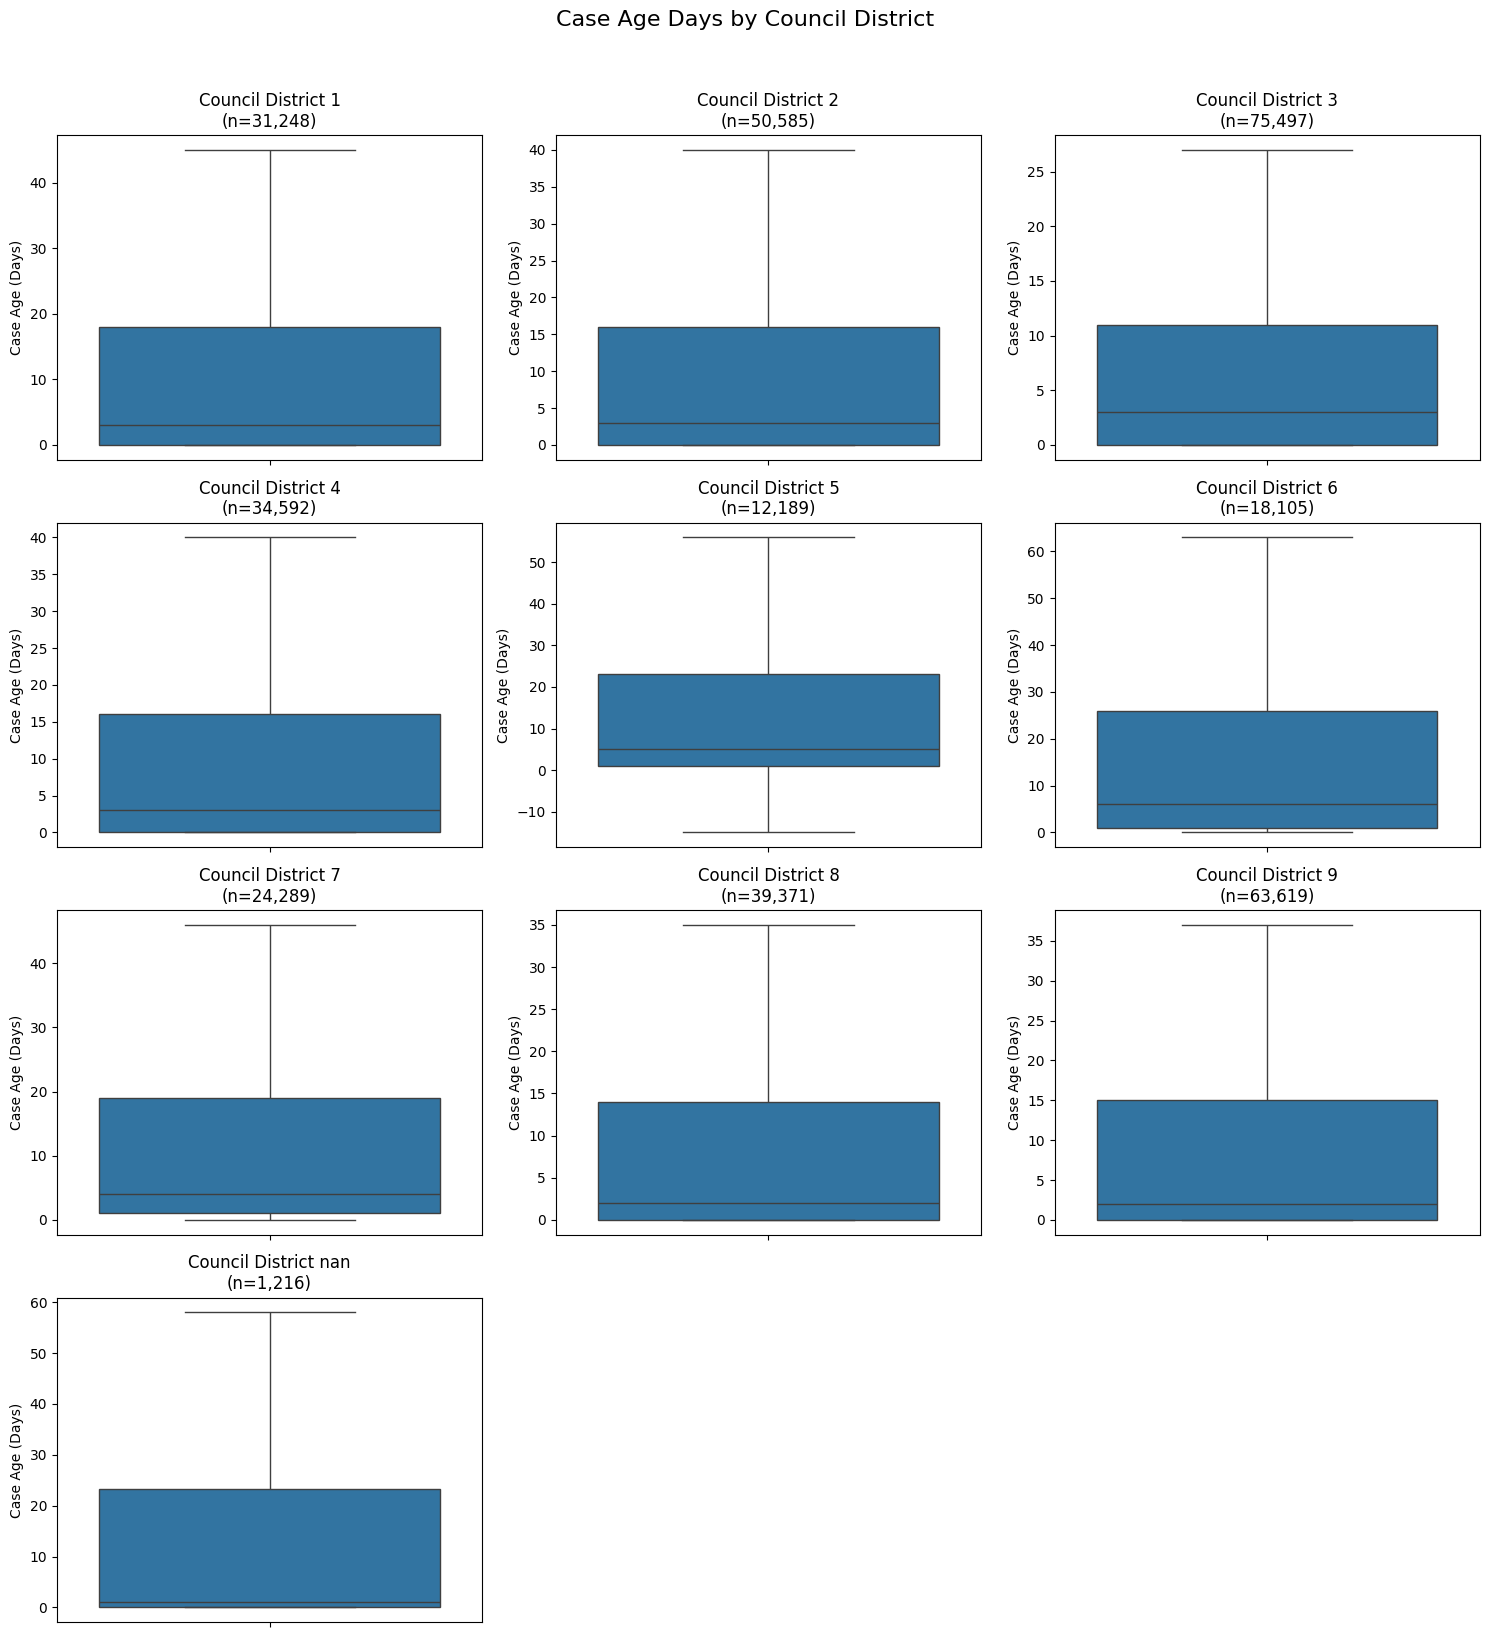

In [22]:
# Get all unique council districts
districts = sorted(
    closed_requests["council_district"].dropna().unique()
)

# Number of plots per row
cols_per_row = 3

# Calculate number of rows
n_rows = math.ceil(len(districts) / cols_per_row)

# Create grid
fig, axes = plt.subplots(
    n_rows,
    cols_per_row,
    figsize=(15, 4 * n_rows)
)

axes = axes.flatten()

# Create one boxplot per council district
for i, district in enumerate(districts):

    subset = closed_requests[
        closed_requests["council_district"] == district
    ]

    sns.boxplot(
        y=subset["case_age_days"],
        ax=axes[i],
        showfliers=False
    )

    axes[i].set_title(
        f"Council District {district}\n(n={len(subset):,})"
    )
    axes[i].set_ylabel("Case Age (Days)")
    axes[i].set_xlabel("")

# Remove unused plots
for j in range(len(districts), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    "Case Age Days by Council District",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

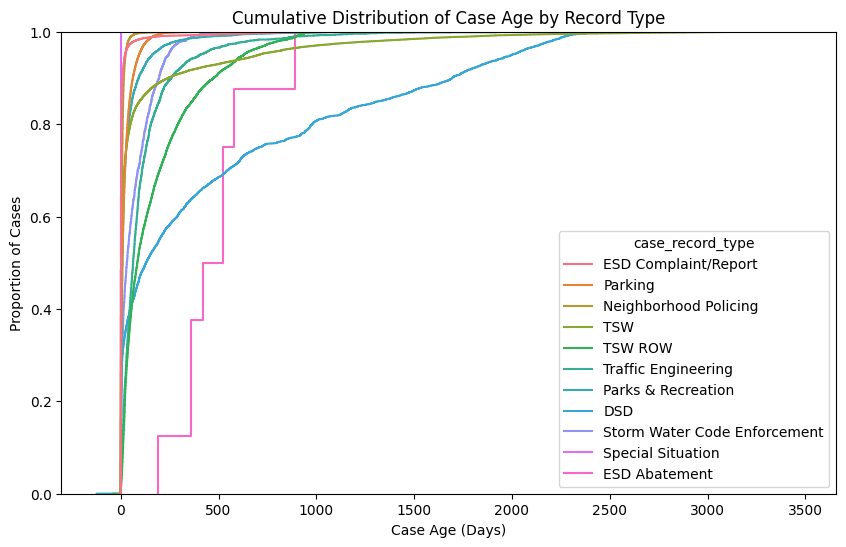

In [23]:
plt.figure(figsize=(10, 6))

sns.ecdfplot(
    data=closed_requests,
    x="case_age_days",
    hue="case_record_type"
)

plt.xlabel("Case Age (Days)")
plt.ylabel("Proportion of Cases")
plt.title("Cumulative Distribution of Case Age by Record Type")
plt.show()

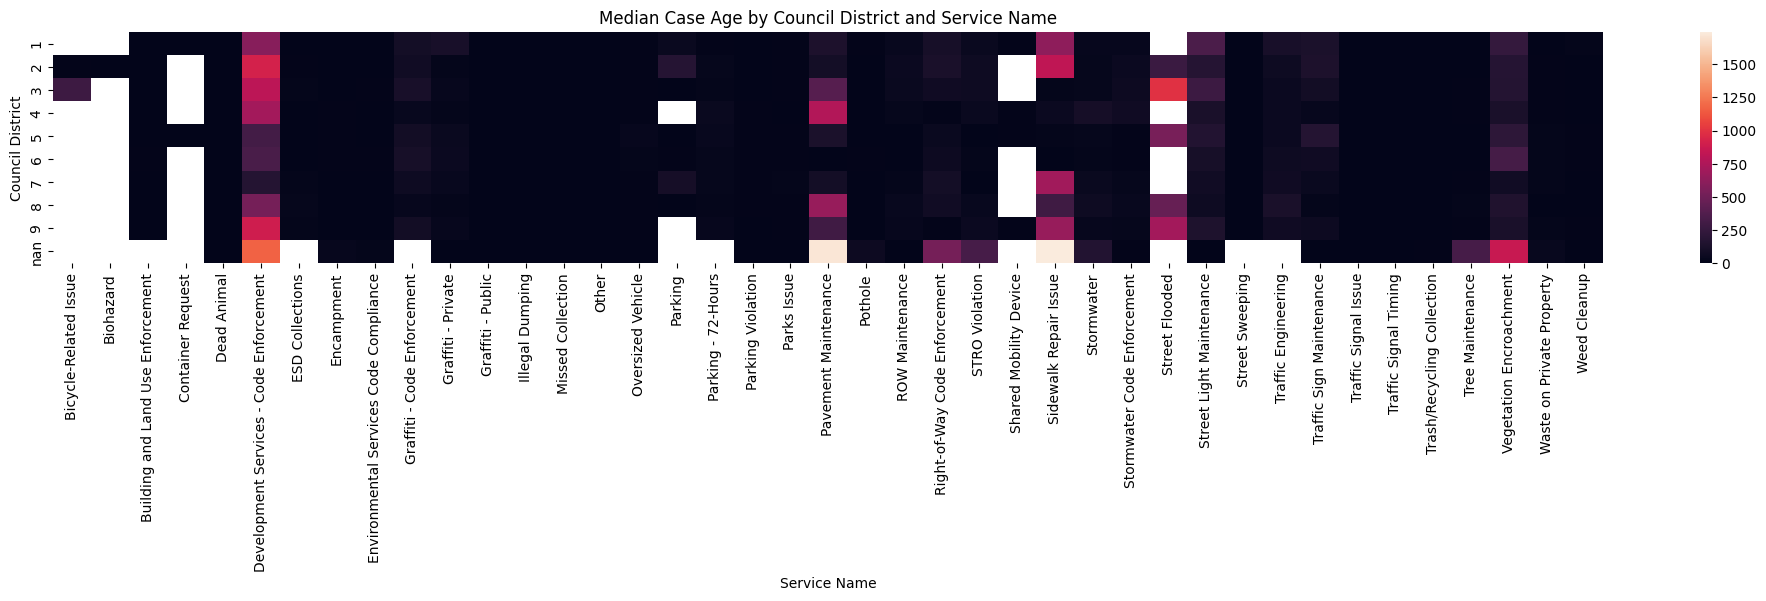

In [24]:
heatmap_data = closed_requests.pivot_table(
    values="case_age_days",
    index="council_district",
    columns="service_name",
    aggfunc="median"
)

plt.figure(figsize=(25, 3))

sns.heatmap(
    heatmap_data,
    #annot=True,
    fmt=".1f"
)

plt.title("Median Case Age by Council District and Service Name")
plt.xlabel("Service Name")
plt.ylabel("Council District")

plt.show()

# ML Prep

select columns needed for ML

In [25]:
ml_df = closed_requests[["service_request_id", "case_age_days", "date_requested", "date_closed", "case_record_type", "service_name", "zipcode", "council_district", "comm_plan_code", "comm_plan_name", "case_origin", "public_description"]]

In [26]:
ml_df

,service_request_id,case_age_days,date_requested,date_closed,case_record_type,service_name,zipcode,council_district,comm_plan_code,comm_plan_name,case_origin,public_description
1,5152705,1,2025-03-19 16:22:00.000,2025-03-20,ESD Complaint/Report,Missed Collection,92109,2,18,MISSION BEACH,Web,Third attempt has not been picked up
2,5152711,27,2025-03-19 16:25:00.000,2025-04-15,Parking,Parking Violation,92117,2,6,CLAIREMONT MESA,Web,Van has been parked for over a month. Windows ...
3,5152712,14,2025-03-19 16:25:00.000,2025-04-02,Neighborhood Policing,Encampment,92101,2,14,MIDWAY-PACIFIC HIGHWAY,Web,A homeless encampment fire was reported at W. ...
4,5152714,3,2025-03-19 16:29:00.000,2025-03-22,Parking,Parking Violation,92110,2,6,CLAIREMONT MESA,Web,Van has been parked on the curb since March 11...
5,5152728,5,2025-03-19 16:37:00.000,2025-03-24,ESD Complaint/Report,Missed Collection,92113,8,37,SOUTHEASTERN SAN DIEGO,Web,Very busy street so I understand if one was mi...
...,...,...,...,...,...,...,...,...,...,...,...,...
378664,4662530,598,2024-03-11 08:48:00.000,2025-10-30,TSW ROW,Right-of-Way Code Enforcement,92128,5,31,Rancho Bernardo,Mobile,Sidewalk eneven
378665,4947796,418,2024-09-28 13:25:00.000,2025-11-20,TSW,Traffic Sign Maintenance,92130,1,21,CARMEL VALLEY,Mobile,On the rightside of eastbound Del Mar Heights ...
378666,5060477,3,2025-01-05 11:22:00.000,2025-01-08,TSW,Pothole,92122,6,99,UNIVERSITY,Web,The entrance to the dog park has a raised edge...
378667,5182329,6,2025-04-12 18:34:00.000,2025-04-18,TSW,Tree Maintenance,92117,2,6,CLAIREMONT MESA,Mobile,Tree blocking sidewalk


In [27]:
meta_df = create_metadata(ml_df)

# Export to CSV file
meta_df.to_csv("metadata_report.csv")

meta_df.head(25)

,dtype,n_unique,missing_sum,is_numeric,is_categorical
service_request_id,int64,350711,0,True,False
case_age_days,int64,2441,0,True,False
date_requested,object,223394,0,False,True
date_closed,object,365,0,False,True
case_record_type,object,11,0,False,True
service_name,object,41,17,False,True
zipcode,object,67,0,False,True
council_district,category,10,0,False,True
comm_plan_code,object,58,0,False,True
comm_plan_name,object,59,1252,False,True


### Dealing with missing values

In [28]:
# drop observations with missing service name
# drop observations with missing zip code

ml_df = ml_df.dropna(
    subset=["service_name", "zipcode", "council_district", "comm_plan_code"]
)

ml_df = ml_df.reset_index(drop=True)

#most_common_origin = ml_df["case_origin"].mode()[0]
#ml_df["case_origin"] = ml_df["case_origin"].fillna(most_common_origin)

In [29]:
meta_df = create_metadata(ml_df)

# Export to CSV file
meta_df.to_csv("metadata_report.csv")

meta_df.head(25)

,dtype,n_unique,missing_sum,is_numeric,is_categorical
service_request_id,int64,350694,0,True,False
case_age_days,int64,2441,0,True,False
date_requested,object,223389,0,False,True
date_closed,object,365,0,False,True
case_record_type,object,11,0,False,True
service_name,object,41,0,False,True
zipcode,object,66,0,False,True
council_district,category,10,0,False,True
comm_plan_code,object,58,0,False,True
comm_plan_name,object,59,1251,False,True


In [30]:
ml_df.shape

(350694, 12)

column for day of week based on date requested, column for season based on date requested, extract text urgent from detail/public description

### Feature Engineering

In [31]:
ml_df["date_requested"] = pd.to_datetime(
    ml_df["date_requested"]
)

ml_df["request_year"] = ml_df["date_requested"].dt.year
ml_df["request_month"] = ml_df["date_requested"].dt.month
ml_df["request_day_of_week"] = ml_df["date_requested"].dt.dayofweek
ml_df["request_quarter"] = ml_df["date_requested"].dt.quarter

In [32]:
ml_df["date_requested"] = pd.to_datetime(ml_df["date_requested"])
ml_df["date_closed"] = pd.to_datetime(ml_df["date_closed"])

# Calculate number of days to close
days_to_close = (
    ml_df["date_closed"] - ml_df["date_requested"]
).dt.days

# Create binary target
ml_df["closed_within_30_days"] = (days_to_close <= 30).astype(int)

In [33]:
urgent_cases = ml_df[
    ml_df["public_description"]
    .fillna("")
    .str.contains("urgent", case=False, na=False)
]

urgent_cases[
    ["service_request_id", "public_description", "case_age_days"]
]

,service_request_id,public_description,case_age_days
1592,5236532,The metal fence at the cormorant nesting site ...,204
2624,5237100,Immediate action is needed regarding severe no...,0
3409,5234436,Here?s a direct and urgent letter you can send...,9
3792,5238874,**URGENT** BROKEN STOP SIGN,2
4671,5238724,I?m following up again regarding the homeless ...,1
...,...,...,...
342408,5485188,This is a second dumpster on the property on O...,6
345572,5416565,URGENT: Silver Prius has been parked here sin...,14
346534,5490955,Two tall palm trees on city sidewalk landscape...,1
349085,5495637,Tree on 8056 san felipe st. Forgot to mention ...,1


In [34]:
urgency_terms = [
    "urgent",
    "urgently",
    "emergency",
    "immediately",
    "immediate",
    "asap",
    "danger",
    "dangerous",
    "hazard",
    "hazardous",
    "unsafe",
    "critical"
]

pattern = "|".join(urgency_terms)

urgent_cases = ml_df[
    ml_df["public_description"]
    .fillna("")
    .str.contains(pattern, case=False, na=False)
]

In [35]:
urgent_cases[
    ["service_request_id", "public_description", "case_age_days"]
].head(5)

,service_request_id,public_description,case_age_days
1,5152711,Van has been parked for over a month. Windows ...,27
18,5152934,Around Kettner and Grape - this area needs imm...,48
53,5153300,"LARGE POTHOLE. DANGEROUS AND HAZARDOUS, PER OF...",0
111,5153877,The new bike lane for Clairemont Dr. is causin...,1
122,5153971,Recently the sidewalk in front of the Windsor ...,26


In [36]:
for term in urgency_terms:
    count = (
        ml_df["public_description"]
        .fillna("")
        .str.contains(term, case=False, na=False)
        .sum()
    )

    print(f"{term}: {count}")

urgent: 276
urgently: 78
emergency: 761
immediately: 760
immediate: 1516
asap: 1195
danger: 4576
dangerous: 3785
hazard: 5899
hazardous: 661
unsafe: 1528
critical: 68


In [37]:
ml_df["urgent_language"] = (
    ml_df["public_description"]
    .fillna("")
    .str.contains(pattern, case=False, na=False)
    .astype(int)
)

In [38]:
ml_df.groupby("urgent_language")["case_age_days"].describe()

,count,mean,std,min,25%,50%,75%,max
urgent_language,,,,,,,,
0,336189.0,45.141941,186.507959,-124.0,0.0,3.0,15.0,3478.0
1,14505.0,141.354498,403.714793,0.0,1.0,8.0,51.0,3367.0


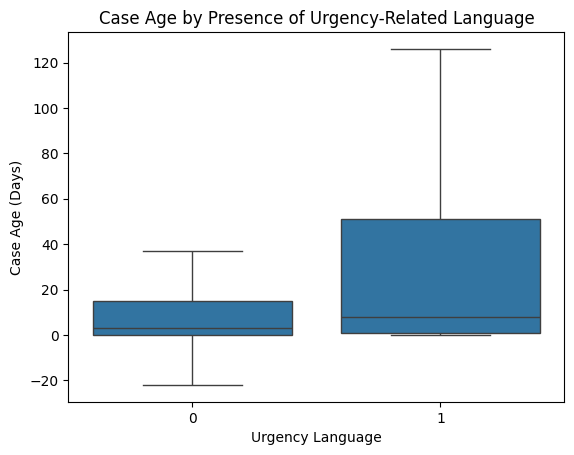

In [39]:
sns.boxplot(
    data=ml_df,
    x="urgent_language",
    y="case_age_days",
    showfliers=False
)

plt.xlabel("Urgency Language")
plt.ylabel("Case Age (Days)")
plt.title("Case Age by Presence of Urgency-Related Language")
plt.show()

In [40]:
ml_df = ml_df.drop(columns = ["public_description", "date_requested", "date_closed"])

In [41]:
ml_df

,service_request_id,case_age_days,case_record_type,service_name,zipcode,council_district,comm_plan_code,comm_plan_name,case_origin,request_year,request_month,request_day_of_week,request_quarter,closed_within_30_days,urgent_language
0,5152705,1,ESD Complaint/Report,Missed Collection,92109,2,18,MISSION BEACH,Web,2025,3,2,1,1,0
1,5152711,27,Parking,Parking Violation,92117,2,6,CLAIREMONT MESA,Web,2025,3,2,1,1,1
2,5152712,14,Neighborhood Policing,Encampment,92101,2,14,MIDWAY-PACIFIC HIGHWAY,Web,2025,3,2,1,1,0
3,5152714,3,Parking,Parking Violation,92110,2,6,CLAIREMONT MESA,Web,2025,3,2,1,1,0
4,5152728,5,ESD Complaint/Report,Missed Collection,92113,8,37,SOUTHEASTERN SAN DIEGO,Web,2025,3,2,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
350689,4662530,598,TSW ROW,Right-of-Way Code Enforcement,92128,5,31,Rancho Bernardo,Mobile,2024,3,0,1,0,0
350690,4947796,418,TSW,Traffic Sign Maintenance,92130,1,21,CARMEL VALLEY,Mobile,2024,9,5,3,0,0
350691,5060477,3,TSW,Pothole,92122,6,99,UNIVERSITY,Web,2025,1,6,1,1,0
350692,5182329,6,TSW,Tree Maintenance,92117,2,6,CLAIREMONT MESA,Mobile,2025,4,5,2,1,0


Separate out dataframes based on variables needed for each ML problem

In [42]:
linear_df = ml_df.drop(columns = ["closed_within_30_days"])
logistic_df = ml_df.drop(columns = ["case_age_days"])
col = logistic_df.pop("closed_within_30_days")
logistic_df.insert(0, "closed_within_30_days", col)
kmeans_df = ml_df.drop(columns = ["closed_within_30_days", "case_age_days"])

In [43]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

### Linear Regression

In [44]:
X = linear_df.drop(
    columns=["service_request_id", "case_age_days"]
)

y = linear_df["case_age_days"]

In [45]:
# Categorical features OTHER than case_origin
categorical_features = [
    "case_record_type",
    "service_name",
    "zipcode",
    "council_district",
    "comm_plan_code",
    "comm_plan_name"
]

# Case origin gets its own preprocessing
case_origin_feature = ["case_origin"]

# Numeric features
numeric_features = [
    "request_year",
    "request_month",
    "request_day_of_week",
    "request_quarter",
    "urgent_language"
]

# Regular categorical variables
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(
            strategy="constant",
            fill_value="Missing"
        )),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore"
        ))
    ]
)

# Case origin: impute with most frequent value, then one-hot encode
case_origin_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(
            strategy="most_frequent"
        )),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore"
        ))
    ]
)

# Numeric variables
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(
            strategy="median"
        ))
    ]
)

# Combine everything
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, categorical_features),
        ("origin", case_origin_transformer, case_origin_feature),
        ("num", numeric_transformer, numeric_features)
    ]
)

In [46]:
# Split data: 80% train, 20% test
# random_state=42 makes the split reproducible

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [47]:
linear_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

In [48]:
linear_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['case_record_type',
                                                   'service_name', 'zipcode',
                                                   'council_district',
                                                   'comm_plan_code',
                                                   'comm_plan_name']),
                                                 ('origin',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['case_origin']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['request_year',
                                                   'request_month',
                                                   'request_day_of_week',
                                                   'request_quarter',
                                                   'urgent_language'])])),
                ('regressor', LinearRegression())])

In [49]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_pred = linear_pipeline.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R-squared: {r2:.2f}")

Mean Squared Error: 3459.24
Root Mean Squared Error: 58.82
R-squared: 0.92


RMSE: average error in days, penalizes big misses more.
MAE: average error in days, treats all errors equally.
R²: proportion of variance in case_age_days explained by the model (0 to 1, higher = better fit).

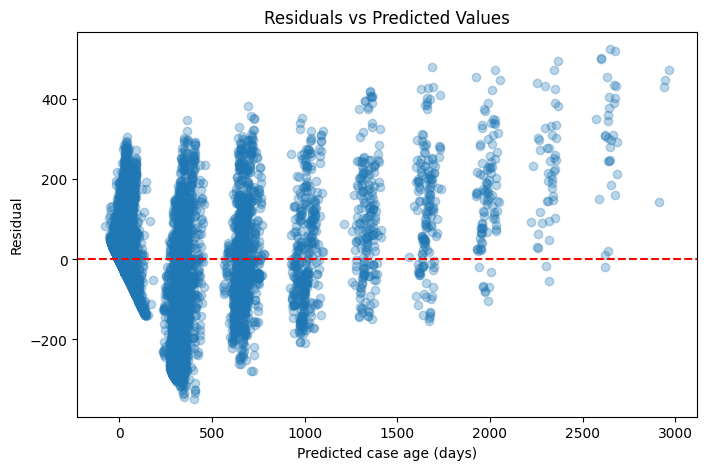

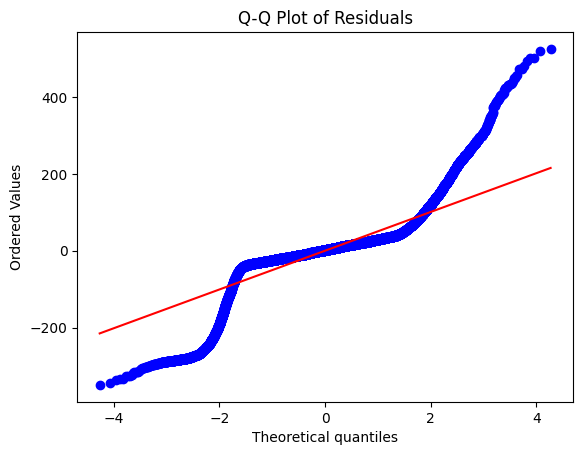

In [50]:
import matplotlib.pyplot as plt

residuals = y_test - y_pred

# Residuals vs predicted
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.3)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted case age (days)")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted Values")
plt.show()

# Q-Q plot for normality of residuals
import scipy.stats as stats
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

In [53]:
y_train_log = np.log1p(y_train.clip(lower=0))
y_test_log = np.log1p(y_test.clip(lower=0))

log_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])
log_pipeline.fit(X_train, y_train_log)

y_pred_log = log_pipeline.predict(X_test)
y_pred_log_backtransformed = np.expm1(y_pred_log)  # back to real days for comparison

rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log_backtransformed))
r2_log = r2_score(y_test, y_pred_log_backtransformed)

print(f"Log-model RMSE (back-transformed): {rmse_log:.2f}")
print(f"Log-model R²: {r2_log:.4f}")

Log-model RMSE (back-transformed): 14449.03
Log-model R²: -5089.3797


In [54]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Add scaling to the numeric pipeline (edit the numeric_transformer from before)
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Rebuild the ColumnTransformer with the updated numeric_transformer
preprocessor = ColumnTransformer(transformers=[
    ("cat", categorical_transformer, categorical_features),
    ("origin", case_origin_transformer, case_origin_feature),
    ("num", numeric_transformer, numeric_features)
])

ridge_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", Ridge())
])

param_grid = {"regressor__alpha": [0.1, 1.0, 10.0, 100.0]}

grid_search = GridSearchCV(
    ridge_pipeline, param_grid, cv=5,
    scoring="neg_root_mean_squared_error"
)
grid_search.fit(X_train, y_train)

print("Best alpha:", grid_search.best_params_)
print("Best CV RMSE:", -grid_search.best_score_)

Best alpha: {'regressor__alpha': 10.0}
Best CV RMSE: 58.32172464273458


In [55]:
best_model = grid_search.best_estimator_
y_pred_ridge = best_model.predict(X_test)

rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"Ridge RMSE: {rmse_ridge:.2f}, R²: {r2_ridge:.4f}")

Ridge RMSE: 58.82, R²: 0.9156


### Logistic Regression

In [ ]:
X = logistic_df.drop(
    columns=["service_request_id", "closed_within_30_days"]
)

y = logistic_df["closed_within_30_days"]

### K Means Classification